In [22]:
import pandas as pd
import pysam
import os
import json

# assemblies

In [23]:
assemblyDict={}
directory='/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split("_")[0]]= directory+file
print(len(assemblyDict))

143


In [24]:
df = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/DavidPorubsky/AZFc_ColorBLock_Clusters_12162025.csv")

In [25]:
rmDict={}
directory='/LeeLab/HPRC/chromosomeY/Data/RepeatMasker/'
for file in os.listdir(directory):
    rmDict[file.split(".")[0]]=directory+file

In [47]:
testDF = pd.read_csv(rmDict['HG01255'], sep='\t')
testDF.columns = testDF.columns.str.strip()
testDF['query_match_start'] = testDF['query_match_start'].astype(int)
testDF['query_match_end'] = testDF['query_match_end'].astype(int)

In [50]:
testDF[(testDF['query_match_start']>=24551071) & (testDF['query_match_end']<=24554504)]

,sw_score,pct_sub,pct_del,pct_ins,query_name,query_match_start,query_match_end,query_remaining_bp,match_orientation,repeat_motif_name,repeat_class_family,repeat_match_start,repeat_match_end,repeat_remaining_bp,repeat_match_id,higher_scoring_overlap
42419,328,21.2,0.0,0.0,HG01255_chrY,24551726,24551791,26340483,-1,MADE2,DNA/TcMar-Mariner,6,74,9,33845,0
42420,1902,24.8,11.8,2.1,HG01255_chrY,24552488,24552792,26339482,1,MER119,DNA/hAT-Charlie,1,356,227,33846,0
42421,2521,8.5,0.0,3.2,HG01255_chrY,24552793,24553111,26339163,1,AluY,SINE/Alu,1,309,2,33847,0
42422,1902,24.8,11.8,2.1,HG01255_chrY,24553112,24553337,26338937,1,MER119,DNA/hAT-Charlie,357,583,0,33846,0
42423,2225,17.6,2.9,2.2,HG01255_chrY,24553344,24553889,26338385,1,LTR12E,LTR/ERV1,1,550,772,33848,0


In [54]:
25939448-25939521

-73

In [51]:
testDF[(testDF['query_match_start']>=25937810) & (testDF['query_match_end']<=25941244)]

,sw_score,pct_sub,pct_del,pct_ins,query_name,query_match_start,query_match_end,query_remaining_bp,match_orientation,repeat_motif_name,repeat_class_family,repeat_match_start,repeat_match_end,repeat_remaining_bp,repeat_match_id,higher_scoring_overlap
44664,2225,17.6,2.9,2.2,HG01255_chrY,25938425,25938970,24953304,-1,LTR12E,LTR/ERV1,772,550,1,35587,0
44665,885,24.2,1.8,1.3,HG01255_chrY,25938977,25939201,24953073,-1,MER119,DNA/hAT-Charlie,0,583,357,35588,0
44666,31,0.0,0.0,0.0,HG01255_chrY,25939203,25939231,24953043,1,(T)n,Simple_repeat,1,29,0,35589,0
44667,307,9.1,0.0,0.0,HG01255_chrY,25939232,25939273,24953001,-1,7SLRNA,srpRNA,21,299,258,35590,1
44668,1156,19.2,1.5,5.4,HG01255_chrY,25939240,25939509,24952765,1,SVA_A,Retroposon/SVA,61,320,1067,35591,0
44669,283,23.0,2.7,0.0,HG01255_chrY,25939448,25939521,24952753,-1,Alu,SINE/Alu,244,76,1,35592,1
44670,863,21.0,0.0,2.4,HG01255_chrY,25939522,25939689,24952585,-1,MER119,DNA/hAT-Charlie,222,361,198,35588,0
44671,328,21.2,0.0,0.0,HG01255_chrY,25940524,25940589,24951685,1,MADE2,DNA/TcMar-Mariner,9,74,6,35593,0


## Read in MSA

In [28]:
#Original DELETION DATAframe to replace with INVERSIONs Below
#bpDF = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/Deletion_Breakpoints/Deletion_Samples_BreakpointWindows.csv')

In [29]:
bpDF1 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/RecurrentInversions/AZFc_Inversion_BreakpointWindows_05012026.csv')
bpDF1['deleted_contig']=[x+"_chrY" for x in bpDF1['Sample']]
bpDF1['breakWindow_start_deleted']=[x for x in bpDF1['Start']]
bpDF1['breakWindow_end_deleted']=[x for x in bpDF1['End']]
bpDF1['breakWindow_len_deleted_bp']=[x for x in bpDF1['WindowSize']]
bpDF1['fullArchitectureSample_contig']=[x for x in bpDF1['Inversion']]
bpDF = bpDF1[['deleted_contig','breakWindow_start_deleted','breakWindow_end_deleted','breakWindow_len_deleted_bp','fullArchitectureSample_contig']].copy()

In [30]:
contigInfo=[]
for contig in set(bpDF['deleted_contig']):
    breakDF = bpDF[bpDF['deleted_contig']==contig].copy()
    blockDF = df[df['contig']==contig].copy()

    for row in breakDF.index:
        start = int(breakDF.at[row, 'breakWindow_start_deleted'])
        end = int(breakDF.at[row, 'breakWindow_end_deleted'])

        test = blockDF[(blockDF['start']<=start) & (blockDF['end']>=end)].reset_index().copy()
        if len(test)==1:
            colorBlock = test.loc[0,'colorblock']
            if 'plus' in colorBlock:
                goodColor = colorBlock.split("-")[0][:-1]+"-plus"

            else:
                goodColor = colorBlock[:-1]
            print(contig, start, end, goodColor, test.loc[0,'start'], test.loc[0,'end'],str(test.loc[0,'orientation']))
            contigInfo.append([contig+":"+str(start)+"-"+str(end), goodColor, contig+":"+str(test.loc[0,'start'])+"-"+str(test.loc[0,'end']),'sense'])

HG01255_chrY 24551071 24554504 red 24431539 24577975 sense
HG01255_chrY 25937810 25941244 red 25914333 26052363 antisense
HG02492_chrY 23510941 23516021 green 23414908 23722046 antisense
HG02492_chrY 25815823 25820904 green 25609825 25916936 sense
HG01952_chrY 24657189 24659323 green 24412515 24719663 antisense
HG01952_chrY 26679233 26681367 green 26618887 26926042 sense
HG01109_chrY 24040377 24045740 blue-plus 24023901 24054603 sense
HG01109_chrY 24875227 24880590 blue-plus 24866366 24897065 antisense
HG02083_chrY 23300554 23326049 green 23081391 23388513 antisense
HG02083_chrY 25374603 25400098 green 25312130 25619271 sense
HG00706_chrY 24352617 24375791 red 24335143 24467089 antisense
HG00706_chrY 26196109 26219272 red 26090292 26236742 sense
HG02514_chrY 23896075 23921570 green 23676897 23984033 antisense
HG02514_chrY 25949706 25975201 green 25887245 26194371 sense
HG02027_chrY 23671687 23678262 green 23667966 23975100 antisense
HG02027_chrY 26192993 26199575 green 25896141 2620329

In [31]:
blockInfoDF = pd.DataFrame(data=contigInfo, columns=['breakpointWindow','color','colorBlockCoordinates','orientation'])

In [32]:
import pandas as pd

def add_relative_positions_with_orientation(
    blockInfoDF: pd.DataFrame,
    *,
    window_col: str = "breakpointWindow",
    block_col: str = "colorBlockCoordinates",
    orientation_col: str = "orientation",
    antisense_value: str = "antisense",
) -> pd.DataFrame:
    """
    Adds relative_start/end/mid (0..1) for breakpointWindow within colorBlockCoordinates,
    and also adds oriented versions where antisense blocks are flipped:
        rel_oriented = 1 - rel

    Output columns:
      block_start, block_end, block_len
      win_start, win_end, win_len, win_mid
      relative_start, relative_end, relative_mid
      relative_start_oriented, relative_end_oriented, relative_mid_oriented
      in_block
    """

    def parse_coords(coord_str: str):
        coord_str = str(coord_str)
        contig, coords = coord_str.split(":", 1)
        s, e = coords.split("-", 1)
        s = int(s)
        e = int(e)
        lo, hi = (s, e) if s <= e else (e, s)
        return contig, lo, hi

    out = blockInfoDF.copy()

    cols = {
        "block_start": [],
        "block_end": [],
        "block_len": [],
        "win_start": [],
        "win_end": [],
        "win_len": [],
        "win_mid": [],
        "relative_start": [],
        "relative_end": [],
        "relative_mid": [],
        "relative_start_oriented": [],
        "relative_end_oriented": [],
        "relative_mid_oriented": [],
        "in_block": [],
    }

    for i in out.index:
        _, b_lo, b_hi = parse_coords(out.at[i, block_col])
        _, w_lo, w_hi = parse_coords(out.at[i, window_col])

        block_len = b_hi - b_lo + 1
        win_len = w_hi - w_lo + 1
        win_mid = (w_lo + w_hi) / 2.0

        in_block = (w_lo >= b_lo) and (w_hi <= b_hi)

        w_clip_lo = max(b_lo, w_lo)
        w_clip_hi = min(b_hi, w_hi)
        w_clip_mid = (w_clip_lo + w_clip_hi) / 2.0

        denom = max(1, block_len - 1)
        rel_start = (w_clip_lo - b_lo) / denom
        rel_end   = (w_clip_hi - b_lo) / denom
        rel_mid   = (w_clip_mid - b_lo) / denom

        orient = str(out.at[i, orientation_col]).strip().lower() if orientation_col in out.columns else "sense"
        if orient == antisense_value.lower():
            o_start = 1.0 - rel_end
            o_end   = 1.0 - rel_start
            o_mid   = 1.0 - rel_mid
        else:
            o_start, o_end, o_mid = rel_start, rel_end, rel_mid

        cols["block_start"].append(b_lo)
        cols["block_end"].append(b_hi)
        cols["block_len"].append(block_len)
        cols["win_start"].append(w_lo)
        cols["win_end"].append(w_hi)
        cols["win_len"].append(win_len)
        cols["win_mid"].append(win_mid)

        cols["relative_start"].append(rel_start)
        cols["relative_end"].append(rel_end)
        cols["relative_mid"].append(rel_mid)

        cols["relative_start_oriented"].append(o_start)
        cols["relative_end_oriented"].append(o_end)
        cols["relative_mid_oriented"].append(o_mid)

        cols["in_block"].append(in_block)

    for k, v in cols.items():
        out[k] = v

    return out


In [33]:
import pandas as pd
from typing import Any, Dict, List

def group_windows_by_color_orient_and_oriented_overlap(
    df: pd.DataFrame,
    *,
    color_col: str = "color",
    orientation_col: str = "orientation",         
    window_col: str = "breakpointWindow",
    rel_start_col: str = "relative_start_oriented", 
    rel_end_col: str = "relative_end_oriented",
    in_block_col: str = "in_block",
    require_in_block: bool = True,
    merge_tolerance: float = 0.01,  
) -> pd.DataFrame:
    """
    Group breakpoint windows whose oriented relative intervals overlap OR are within
    `merge_tolerance` (gap <= tolerance), but keep groups separate across orientations.

    Grouping is performed within each (color, orientation) subset.
    Oriented coordinates are still used for interval positions (antisense is flipped upstream).
    """

    out_rows: List[Dict[str, Any]] = []
    work = df.copy()

    if require_in_block and in_block_col in work.columns:
        work = work[work[in_block_col] == True].copy()

    needed = [color_col, orientation_col, window_col, rel_start_col, rel_end_col]
    missing = [c for c in needed if c not in work.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    work[rel_start_col] = pd.to_numeric(work[rel_start_col], errors="coerce")
    work[rel_end_col]   = pd.to_numeric(work[rel_end_col], errors="coerce")
    work = work.dropna(subset=needed).copy()

    work["lo"] = work[[rel_start_col, rel_end_col]].min(axis=1)
    work["hi"] = work[[rel_start_col, rel_end_col]].max(axis=1)

    def flush_group(color_val, orient_val, gid, members):
        if not members:
            return
        g_lo = min(m["lo"] for m in members)
        g_hi = max(m["hi"] for m in members)
        g_size = len(members)
        for m in members:
            out_rows.append({
                color_col: color_val,
                orientation_col: orient_val,
                "overlap_group_id": gid,     
                window_col: m["win"],
                rel_start_col: m["lo"],
                rel_end_col: m["hi"],
                "group_rel_start": g_lo,
                "group_rel_end": g_hi,
                "group_size": g_size,
            })


    for (color_val, orient_val), sub in work.groupby([color_col, orientation_col], sort=False):
        sub = sub.sort_values(["lo", "hi", window_col]).copy()

        group_id = 0
        current_end = None
        members = []

        for win, lo, hi in sub[[window_col, "lo", "hi"]].itertuples(index=False, name=None):
            if current_end is None:
                group_id += 1
                current_end = hi
                members = [{"win": win, "lo": lo, "hi": hi}]
            else:
                if lo <= current_end + merge_tolerance:
                    members.append({"win": win, "lo": lo, "hi": hi})
                    current_end = max(current_end, hi)
                else:
                    flush_group(color_val, orient_val, group_id, members)
                    group_id += 1
                    current_end = hi
                    members = [{"win": win, "lo": lo, "hi": hi}]

        flush_group(color_val, orient_val, group_id, members)

    return pd.DataFrame(out_rows)


In [34]:
blockInfoDF2 = add_relative_positions_with_orientation(blockInfoDF)
groupsDF = group_windows_by_color_orient_and_oriented_overlap(blockInfoDF2, merge_tolerance=0.01)

In [35]:
import pandas as pd

windowBlockDict = {}
blockInfoDF["Repeats"] = None 

_rm_cache = {}

for row in blockInfoDF.index:
    bp_window = str(blockInfoDF.at[row, "breakpointWindow"])

    try:
        windowStart = int(bp_window.split(":")[1].split("-")[0])
        windowEnd   = int(bp_window.split(":")[1].split("-")[1])
    except Exception:
        blockInfoDF.at[row, "Repeats"] = {}
        continue

    win_lo, win_hi = (windowStart, windowEnd) if windowStart <= windowEnd else (windowEnd, windowStart)

    coord_str = str(blockInfoDF.at[row, "colorBlockCoordinates"])
    if ":" not in coord_str or "-" not in coord_str.split(":", 1)[1]:
        blockInfoDF.at[row, "Repeats"] = {}
        continue

    contig, coords = coord_str.split(":", 1)
    start_str, end_str = coords.split("-", 1)

    try:
        start = int(start_str)
        end   = int(end_str)
    except ValueError:
        blockInfoDF.at[row, "Repeats"] = {}
        continue

    w_lo, w_hi = (start, end) if start <= end else (end, start)

    block_len = w_hi - w_lo + 1
    win_len   = win_hi - win_lo + 1

    inter_win_lo = max(w_lo, win_lo)
    inter_win_hi = min(w_hi, win_hi)
    win_inside_len = max(0, inter_win_hi - inter_win_lo + 1)

    block_minus_window_len = block_len - win_inside_len
    if block_minus_window_len <= 0:
        blockInfoDF.at[row, "Repeats"] = {"BlockSize": int(block_len), "WindowSizeInBlock": int(win_inside_len),
                                          "BlockMinusWindowSize": int(block_minus_window_len)}
        windowBlockDict[bp_window] = blockInfoDF.at[row, "Repeats"]
        continue

    sample = contig.split("_")[0]

    if sample not in rmDict:
        blockInfoDF.at[row, "Repeats"] = {}
        continue

    if sample not in _rm_cache:
        rmDF = pd.read_csv(rmDict[sample], sep="\t").copy()
        rmDF["query_match_start"] = pd.to_numeric(rmDF["query_match_start"], errors="coerce")
        rmDF["query_match_end"]   = pd.to_numeric(rmDF["query_match_end"], errors="coerce")
        rmDF = rmDF.dropna(subset=["query_match_start", "query_match_end"]).copy()
        _rm_cache[sample] = rmDF
    else:
        rmDF = _rm_cache[sample]

    rm_sub = rmDF[rmDF["query_name"] == contig].copy()
    if rm_sub.empty:
        blockInfoDF.at[row, "Repeats"] = {"BlockSize": int(block_len),
                                          "WindowSizeInBlock": int(win_inside_len),
                                          "BlockMinusWindowSize": int(block_minus_window_len)}
        windowBlockDict[bp_window] = blockInfoDF.at[row, "Repeats"]
        continue

    s = rm_sub["query_match_start"].astype(int)
    e = rm_sub["query_match_end"].astype(int)
    rm_lo = s.where(s <= e, e)
    rm_hi = e.where(s <= e, s)

    mask = (rm_lo <= w_hi) & (rm_hi >= w_lo)
    ov = rm_sub.loc[mask].copy()
    if ov.empty:
        blockInfoDF.at[row, "Repeats"] = {"BlockSize": int(block_len),
                                          "WindowSizeInBlock": int(win_inside_len),
                                          "BlockMinusWindowSize": int(block_minus_window_len)}
        windowBlockDict[bp_window] = blockInfoDF.at[row, "Repeats"]
        continue

    s2 = ov["query_match_start"].astype(int)
    e2 = ov["query_match_end"].astype(int)
    lo2 = s2.where(s2 <= e2, e2)
    hi2 = e2.where(s2 <= e2, s2)

    block_ov = (pd.concat([hi2, pd.Series(w_hi, index=hi2.index)], axis=1).min(axis=1) -
                pd.concat([lo2, pd.Series(w_lo, index=lo2.index)], axis=1).max(axis=1) + 1).clip(lower=0)

    win_ov = (pd.concat([hi2, pd.Series(inter_win_hi, index=hi2.index)], axis=1).min(axis=1) -
              pd.concat([lo2, pd.Series(inter_win_lo, index=hi2.index)], axis=1).max(axis=1) + 1).clip(lower=0)

    block_minus_win_ov = (block_ov - win_ov).clip(lower=0)

    ov = ov.assign(overlap_bp_block_minus_window=block_minus_win_ov)

    bpDict = (ov.groupby("repeat_class_family")["overlap_bp_block_minus_window"]
                .sum()
                .astype(int)
                .to_dict())

    bpDict["BlockSize"] = int(block_len)
    bpDict["WindowSizeInBlock"] = int(win_inside_len)
    bpDict["BlockMinusWindowSize"] = int(block_minus_window_len)

    blockInfoDF.at[row, "Repeats"] = bpDict
    windowBlockDict[bp_window] = bpDict

In [36]:
bpDF['RepeatPercentages']='NONE_FOUND'
bpDF['RepeatBP']='NONE_FOUND'
for contig in bpDF["deleted_contig"].unique():
    sample = contig.split("_")[0]
    rmDF = pd.read_csv(rmDict[sample], sep="\t").copy()

    rmDF["query_match_start"] = pd.to_numeric(rmDF["query_match_start"], errors="coerce")
    rmDF["query_match_end"]   = pd.to_numeric(rmDF["query_match_end"], errors="coerce")
    rmDF = rmDF.dropna(subset=["query_match_start", "query_match_end"])

    tempWindows = bpDF[bpDF["deleted_contig"] == contig].copy()

    for w_idx in tempWindows.index:
        start = int(tempWindows.at[w_idx, "breakWindow_start_deleted"])
        end   = int(tempWindows.at[w_idx, "breakWindow_end_deleted"])
        w_lo, w_hi = (start, end) if start <= end else (end, start)

        mask = (rmDF["query_match_start"] <= w_hi) & (rmDF["query_match_end"] >= w_lo)
        ov = rmDF.loc[mask].copy()
        ov['Size']=ov['query_match_end']-ov['query_match_start']

        newList=[]
        for row in ov.index:
            start2 = int(ov.at[row,'query_match_start'])
            end2 = int(ov.at[row,'query_match_end'])
            for i in range(start2, end2+1):
                if i >=start and i <= end:
                    newList.append([i, ov.at[row,'repeat_motif_name'],ov.at[row,'repeat_class_family'],1, 1/int(tempWindows.at[w_idx, "breakWindow_len_deleted_bp"])])
        
                    
        repeatDF = pd.DataFrame(data=newList)
        percentDict={}
        bpDict={}
        for x in set(repeatDF[2]):
            repeatDF2 = repeatDF[repeatDF[2]==x].copy()
            percentDict[x]=sum(repeatDF2[4])
            bpDict[x]=sum(repeatDF2[3])
        
        bpDF.at[w_idx,'RepeatPercentages']=percentDict
        bpDF.at[w_idx,'RepeatBP']=bpDict

In [37]:
import ast
percentComps=[]
for row in bpDF.index:
    name = str(bpDF.at[row,'deleted_contig'])+":"+str(bpDF.at[row,'breakWindow_start_deleted'])+"-"+str(bpDF.at[row,'breakWindow_end_deleted'])

    bpDictTemp=ast.literal_eval(str(bpDF.at[row,'RepeatBP']))
    for repeat, percentage in ast.literal_eval(str(bpDF.at[row,'RepeatPercentages'])).items():
        percentComps.append([name, repeat, percentage,bpDF.at[row,'fullArchitectureSample_contig'], bpDictTemp[repeat], bpDF.at[row,'breakWindow_len_deleted_bp']])

percentDF = pd.DataFrame(data=percentComps, columns=['Deletion_Window','Repeat','Percentage','ComparisonSample', 'basepair', 'windowLength'])

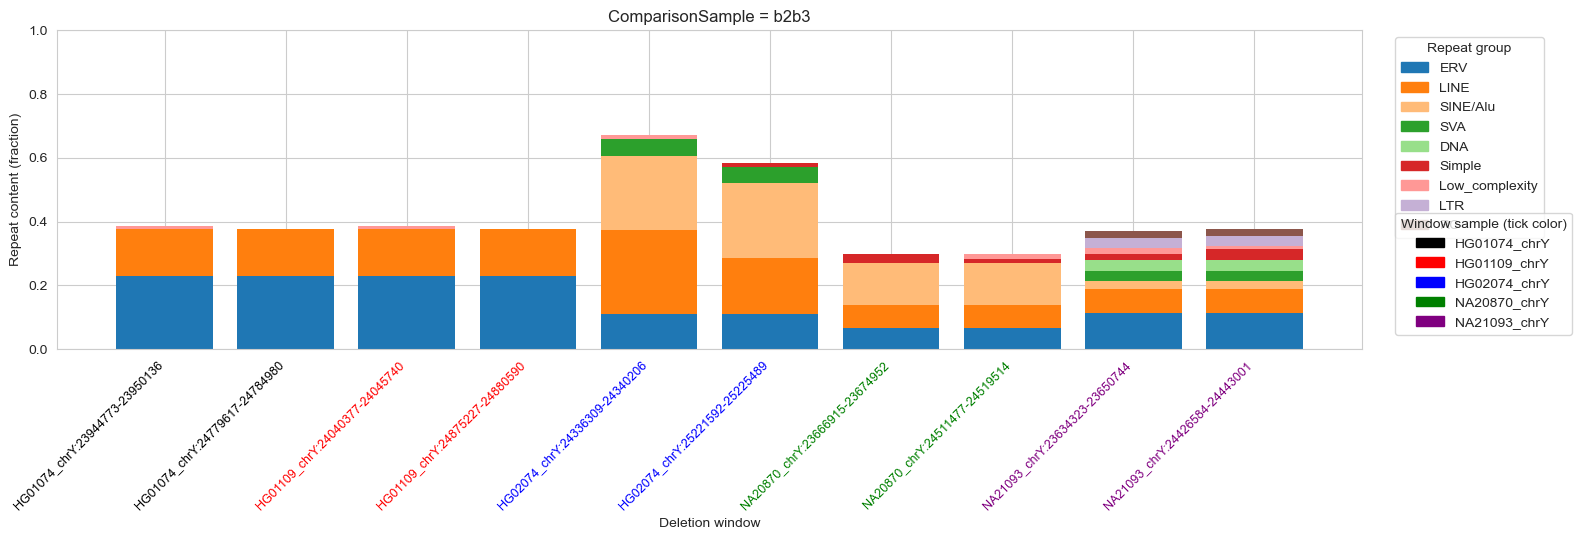

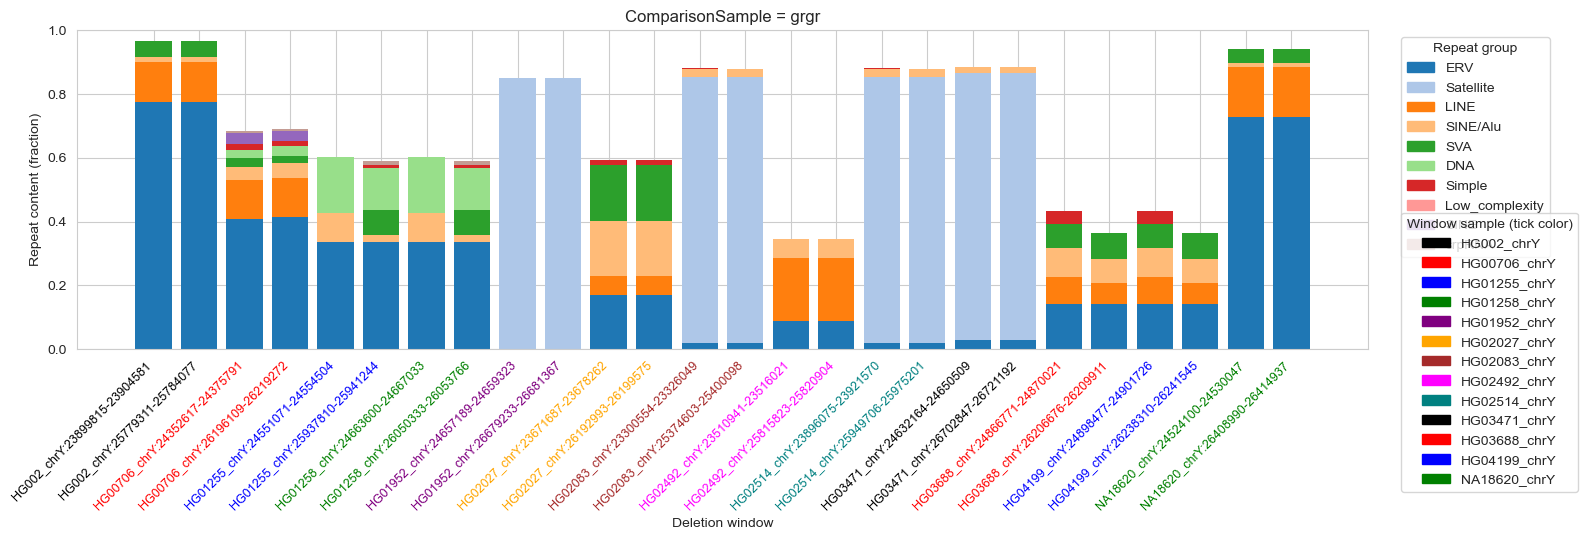

In [38]:
import os
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


df_plot = percentDF.copy()
df_plot["Percentage"] = pd.to_numeric(df_plot["Percentage"], errors="coerce").fillna(0)

def consolidate_repeat(r: str) -> str:
    if pd.isna(r):
        return "Other"
    s = str(r).strip()
    u = s.upper()

    if "ERV" in u:
        return "ERV"
    if "LINE" in u:
        return "LINE"
    if "SINE" in u:
        if "ALU" in u:
            return "SINE/Alu"
        return "SINE"
    if "ALU" in u:
        return "SINE/Alu"
    if "SVA" in u:
        return "SVA"
    if "LTR" in u:
        return "LTR"
    if "DNA" in u:
        return "DNA"
    if "SATELLITE" in u or re.search(r"\bSAT\b", u):
        return "Satellite"
    if "SIMPLE" in u:
        return "Simple"
    if "LOW" in u and "COMPLEX" in u:
        return "Low_complexity"

    if "/" in s:
        return s.split("/", 1)[0]
    return s

df_plot["RepeatGroup"] = df_plot["Repeat"].apply(consolidate_repeat)


df_plot = (df_plot
           .groupby(["ComparisonSample", "Deletion_Window", "RepeatGroup"], as_index=False)["Percentage"]
           .sum())


repeat_order = (
    df_plot.groupby("RepeatGroup")["Percentage"].sum()
    .sort_values(ascending=False)
    .index
)

palette = sns.color_palette("tab20", n_colors=len(repeat_order))
repeat2color = {rep: palette[i] for i, rep in enumerate(repeat_order)}


if "Other" in repeat2color:
    repeat2color["Other"] = (0.7, 0.7, 0.7)

def parse_window(w: str):
    """Expects: sample_chrY:start-end -> (sample_chrY, start, end)"""
    w = str(w)
    if ":" in w:
        sample_part, coords = w.split(":", 1)
    else:
        return (w, 10**18, 10**18)

    m = re.match(r"(\d+)-(\d+)", coords)
    if m:
        start = int(m.group(1))
        end = int(m.group(2))
    else:
        start, end = 10**18, 10**18
    return (sample_part, start, end)

def sort_key_window(w: str):
    sample_part, start, end = parse_window(w)
    return (sample_part, start, end)

def figure_width(n_bars: int) -> float:
    w = 6.5 + 1.05 * max(0, n_bars - 1)
    return min(max(w, 6.5), 16.0)

def sample_color_map(samples):
    palette2 = ["black", "red", "blue", "green", "purple", "orange", "brown", "magenta", "teal"]
    return {s: palette2[i % len(palette2)] for i, s in enumerate(samples)}

sns.set_style("whitegrid")

outdir = "/repeat_stacks"
if outdir is not None:
    os.makedirs(outdir, exist_ok=True)

for comp_sample, sub in df_plot.groupby("ComparisonSample", sort=True):

    wide = (sub.pivot_table(index="Deletion_Window",
                            columns="RepeatGroup",
                            values="Percentage",
                            aggfunc="sum")
              .reindex(columns=repeat_order)
              .fillna(0))

    wide = wide.loc[sorted(wide.index, key=sort_key_window)]
    if wide.shape[0] == 0:
        continue

    window_samples = [parse_window(w)[0] for w in wide.index]
    unique_window_samples = []
    seen = set()
    for s in window_samples:
        if s not in seen:
            unique_window_samples.append(s)
            seen.add(s)
    tick_color = sample_color_map(unique_window_samples)

    n_windows = len(wide)
    fig, ax = plt.subplots(figsize=(figure_width(n_windows), 5.5))

    x = list(range(n_windows))
    bottom = None

    cols_present = [c for c in wide.columns if wide[c].sum() > 0]

    repeat_handles = []
    for rep in cols_present:
        vals = wide[rep].to_numpy()
        ax.bar(x, vals, bottom=bottom, linewidth=0, color=repeat2color.get(rep, None))
        bottom = vals if bottom is None else bottom + vals
        repeat_handles.append(mpatches.Patch(color=repeat2color.get(rep, (0.5, 0.5, 0.5)), label=rep))

    ax.set_xticks(x)
    ax.set_xticklabels(wide.index, rotation=45, ha="right", fontsize=9)
    for lbl, w in zip(ax.get_xticklabels(), wide.index):
        s = parse_window(w)[0]
        lbl.set_color(tick_color.get(s, "black"))

    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Repeat content (fraction)")
    ax.set_xlabel("Deletion window")
    ax.set_title(f"ComparisonSample = {comp_sample}")

    repeat_leg = ax.legend(handles=repeat_handles, title="Repeat group",
                           bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

    if len(unique_window_samples) > 1:
        tick_handles = [mpatches.Patch(color=tick_color[s], label=s) for s in unique_window_samples]
        tick_leg = ax.legend(handles=tick_handles, title="Window sample (tick color)",
                             bbox_to_anchor=(1.02, 0.45), loc="upper left", frameon=True)
        ax.add_artist(repeat_leg)

    fig.tight_layout()

    if outdir is not None:
        safe = str(comp_sample).replace("/", "_")
        #fig.savefig(os.path.join(outdir, f"stacked_repeats_{safe}.jpeg"),
        #            dpi=300, bbox_inches="tight")
        #fig.savefig(os.path.join(outdir, f"stacked_repeats_{safe}.pdf"),
        #           bbox_inches="tight")

    plt.show()


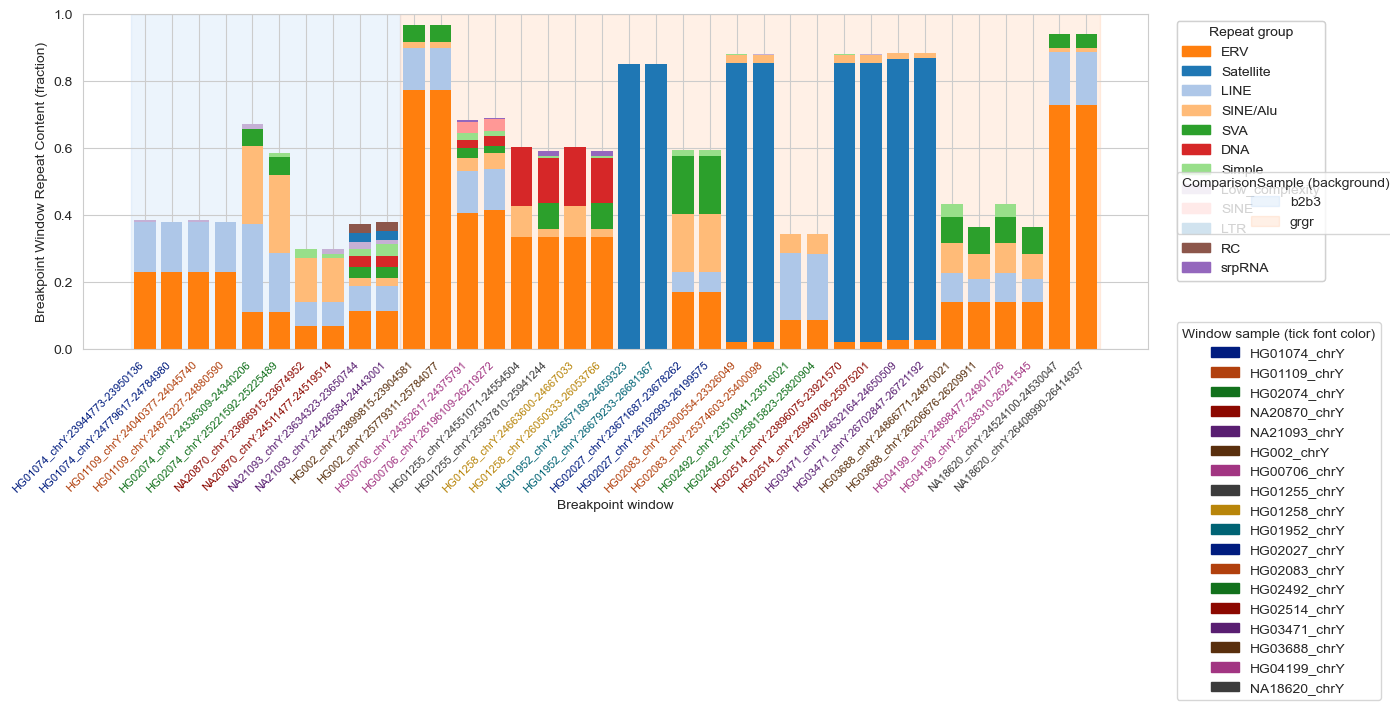

In [39]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_plot = percentDF.copy()
df_plot["Percentage"] = pd.to_numeric(df_plot["Percentage"], errors="coerce").fillna(0)

def consolidate_repeat(r: str) -> str:
    if pd.isna(r):
        return "Other"
    s = str(r).strip()
    u = s.upper()

    if "ERV" in u:
        return "ERV"
    if "LINE" in u:
        return "LINE"
    if "SINE" in u:
        if "ALU" in u:
            return "SINE/Alu"
        return "SINE"
    if "ALU" in u:
        return "SINE/Alu"
    if "SVA" in u:
        return "SVA"
    if "LTR" in u:
        return "LTR"
    if "DNA" in u:
        return "DNA"
    if "SATELLITE" in u or re.search(r"\bSAT\b", u):
        return "Satellite"
    if "SIMPLE" in u:
        return "Simple"
    if "LOW" in u and "COMPLEX" in u:
        return "Low_complexity"

    if "/" in s:
        return s.split("/", 1)[0]
    return s

df_plot["RepeatGroup"] = df_plot["Repeat"].apply(consolidate_repeat)

df_plot = (df_plot
           .groupby(["ComparisonSample", "Deletion_Window", "RepeatGroup"], as_index=False)["Percentage"]
           .sum())

repeat_order = (
    df_plot.groupby("RepeatGroup")["Percentage"].sum()
    .sort_values(ascending=False)
    .index
)
repeat_palette = sns.color_palette("tab20", n_colors=len(repeat_order))
repeat2color = {rep: repeat_palette[i] for i, rep in enumerate(repeat_order)}
repeat2color={'Satellite': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'LINE': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 'ERV': (1.0, 0.4980392156862745, 0.054901960784313725),
 'LTR': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'SINE/Alu': (1.0, 0.7333333333333333, 0.47058823529411764),
 'SVA': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'Simple': (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
 'DNA': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 'SINE': (1.0, 0.596078431372549, 0.5882352941176471),
 'srpRNA': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 'Low_complexity': (0.7725490196078432,
  0.6901960784313725,
  0.8352941176470589),
             'RC': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354)}


if "Other" in repeat2color:
    repeat2color["Other"] = (0.7, 0.7, 0.7)

# -----------------------------
# Parse/sort Deletion_Window
# -----------------------------
def parse_window(w: str):
    """sample_chrY:start-end -> (sample_chrY, start, end)"""
    w = str(w)
    if ":" in w:
        sample_part, coords = w.split(":", 1)
    else:
        return (w, 10**18, 10**18)
    m = re.match(r"(\d+)-(\d+)", coords)
    if m:
        start = int(m.group(1))
        end = int(m.group(2))
    else:
        start, end = 10**18, 10**18
    return (sample_part, start, end)

def sort_key_window(w: str):
    sample_part, start, end = parse_window(w)
    return (sample_part, start, end)


wide = (df_plot.pivot_table(index=["ComparisonSample", "Deletion_Window"],
                            columns="RepeatGroup",
                            values="Percentage",
                            aggfunc="sum")
              .reindex(columns=repeat_order)
              .fillna(0))

wide = wide.reset_index()
wide["__sort_sample"] = wide["Deletion_Window"].apply(lambda x: sort_key_window(x)[0])
wide["__sort_start"]  = wide["Deletion_Window"].apply(lambda x: sort_key_window(x)[1])
wide["__sort_end"]    = wide["Deletion_Window"].apply(lambda x: sort_key_window(x)[2])

wide = wide.sort_values(["ComparisonSample", "__sort_sample", "__sort_start", "__sort_end"]).drop(
    columns=["__sort_sample", "__sort_start", "__sort_end"]
)

x_labels = wide["Deletion_Window"].tolist()
comp_labels = wide["ComparisonSample"].tolist()
sample_labels = [parse_window(w)[0] for w in x_labels]  # sample_chrY for each tick

mat = wide.set_index(["ComparisonSample", "Deletion_Window"])[repeat_order]


bg_palette = sns.color_palette("pastel", n_colors=len(set(comp_labels)))
comp2bg = {c: bg_palette[i] for i, c in enumerate(sorted(set(comp_labels)))}

unique_samples = list(dict.fromkeys(sample_labels))  # preserve first-seen order
sample_palette = sns.color_palette("dark", n_colors=len(unique_samples))
sample2font = {s: sample_palette[i] for i, s in enumerate(unique_samples)}


sns.set_style("whitegrid")

n_bars = mat.shape[0]
fig_w = min(max(14, 0.35 * n_bars), 34)
fig, ax = plt.subplots(figsize=(fig_w, 7))

x = list(range(n_bars))
bottom = None

cols_present = [c for c in mat.columns if mat[c].sum() > 0]
for rep in cols_present:
    vals = mat[rep].to_numpy()
    ax.bar(x, vals, bottom=bottom, linewidth=0, color=repeat2color.get(rep, None))
    bottom = vals if bottom is None else bottom + vals

start = 0
for i in range(1, len(comp_labels) + 1):
    if i == len(comp_labels) or comp_labels[i] != comp_labels[start]:
        end = i - 1
        c = comp_labels[start]
        ax.axvspan(start - 0.5, end + 0.5, color=comp2bg[c], alpha=0.20, zorder=0)
        start = i

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)

for lbl, samp in zip(ax.get_xticklabels(), sample_labels):
    lbl.set_color(sample2font.get(samp, "black"))

ax.set_ylim(0, 1.0)
ax.set_ylabel("Breakpoint Window Repeat Content (fraction)")
ax.set_xlabel("Breakpoint window")

# Legends
repeat_handles = [mpatches.Patch(color=repeat2color[rep], label=rep) for rep in cols_present]
leg1 = ax.legend(handles=repeat_handles, title="Repeat group",
                 bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

comp_handles = [mpatches.Patch(color=comp2bg[c], alpha=0.20, label=c) for c in sorted(set(comp_labels))]
leg2 = ax.legend(handles=comp_handles, title="ComparisonSample (background)",
                 bbox_to_anchor=(1.02, 0.55), loc="upper left", frameon=True)
ax.add_artist(leg1)

SHOW_SAMPLE_TICK_LEGEND = True
if SHOW_SAMPLE_TICK_LEGEND:
    samp_handles = [mpatches.Patch(color=sample2font[s], label=s) for s in unique_samples]
    leg3 = ax.legend(handles=samp_handles, title="Window sample (tick font color)",
                     bbox_to_anchor=(1.02, 0.10), loc="upper left", frameon=True)
    ax.add_artist(leg1)
    ax.add_artist(leg2)

fig.tight_layout()
#fig.savefig(os.path.join(outdir, f"stacked_repeats_combined_INVERSIONS_{safe}.pdf"),
#                    bbox_inches="tight")
plt.show()


In [40]:
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

winDF = percentDF.copy()

winDF["basepair"] = pd.to_numeric(winDF["basepair"], errors="coerce")
winDF["windowLength"] = pd.to_numeric(winDF["windowLength"], errors="coerce")
winDF = winDF.dropna(subset=["Deletion_Window", "Repeat", "basepair", "windowLength"]).copy()

bg_rows = []
for win, d in windowBlockDict.items():
    if not isinstance(d, dict) or len(d) == 0:
        continue

    bg_len = d.get("BlockMinusWindowSize", None)
    if bg_len is None:

        bg_len = d.get("BlockSize", None)

    for rep, bp in d.items():
        if rep in {"BlockSize", "WindowSizeInBlock", "BlockMinusWindowSize"}:
            continue

        bg_rows.append({
            "Deletion_Window": win,
            "Repeat": rep,
            "bg_basepair": bp,
            "bg_length": bg_len
        })

bgDF = pd.DataFrame(bg_rows)

bgLenDF = pd.DataFrame([
    {"Deletion_Window": win, "bg_length": d.get("BlockMinusWindowSize", np.nan)}
    for win, d in windowBlockDict.items()
    if isinstance(d, dict)
])

testDF = (winDF
          .merge(bgDF, on=["Deletion_Window", "Repeat"], how="left")
          .merge(bgLenDF, on="Deletion_Window", how="left", suffixes=("", "_lenfix")))


testDF["bg_basepair"] = testDF["bg_basepair"].fillna(0)

testDF["bg_length"] = testDF["bg_length"].fillna(testDF["bg_length_lenfix"])
testDF = testDF.drop(columns=["bg_length_lenfix"])

testDF["bg_length"] = pd.to_numeric(testDF["bg_length"], errors="coerce")
testDF = testDF.dropna(subset=["bg_length"]).copy()
testDF = testDF[(testDF["bg_length"] > 0) & (testDF["windowLength"] > 0)].copy()

results = []

for row in testDF.itertuples(index=False):
    W_R = int(round(row.basepair))
    W_total = int(round(row.windowLength))
    W_notR = max(0, W_total - W_R)

    B_R = int(round(row.bg_basepair))
    B_total = int(round(row.bg_length))
    B_notR = max(0, B_total - B_R)

    if W_R < 0 or W_notR < 0 or B_R < 0 or B_notR < 0:
        continue

    table = np.array([
        [W_R, W_notR],
        [B_R, B_notR]
    ])


    oddsratio, pval = fisher_exact(table, alternative="greater")
    window_frac = W_R / W_total if W_total else np.nan
    bg_frac = B_R / B_total if B_total else np.nan

    if B_R == 0:
        fold = np.inf if W_R > 0 else 1.0
    else:
        fold = window_frac / bg_frac

    results.append({
        "Deletion_Window": row.Deletion_Window,
        "ComparisonSample": row.ComparisonSample,
        "Repeat": row.Repeat,
        "window_bp": W_R,
        "window_len": W_total,
        "bg_bp": B_R,
        "bg_len": B_total,
        "window_fraction": window_frac,
        "bg_fraction": bg_frac,
        "fold_enrichment": fold,
        "oddsratio": oddsratio,
        "pvalue": pval
    })

resDF = pd.DataFrame(results)
resDF["padj"] = multipletests(resDF["pvalue"], method="fdr_bh")[1]

resDF = resDF.sort_values(["padj", "fold_enrichment"], ascending=[True, False])

In [41]:
sigDF = resDF[(resDF['padj']<0.05) & (resDF['window_fraction']>0.10)].copy()
pooled = (
    sigDF.groupby("Repeat", as_index=False)
    .agg(
        mean_fold=("fold_enrichment","mean"),
        median_fold=("fold_enrichment","median"),
        n_sig=("padj", lambda x: (x < 0.05).sum()),
        n_tests=("padj","size")
    )
    .sort_values(by=['median_fold'], ascending=False)
)
pooled

,Repeat,mean_fold,median_fold,n_sig,n_tests
3,Retroposon/SVA,15.365727,15.365727,2,2
0,DNA/hAT-Charlie,11.568556,11.574316,4,4
2,LTR/ERV1,inf,7.776913,16,16
4,SINE/Alu,5.668149,5.708963,4,4
1,LINE/L1,2.631536,2.631536,4,4
5,Satellite,2.398625,2.432162,8,8


In [42]:
import re
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

def collapse_repeat(r: str) -> str:
    if pd.isna(r):
        return "Other"
    s = str(r).strip()
    u = s.upper()

    if "ERV" in u:
        return "ERV"
    if "LINE" in u:
        return "LINE"
    if "SINE" in u:
        if "ALU" in u:
            return "SINE/Alu"
        return "SINE"
    if "ALU" in u:
        return "SINE/Alu"
    if "SVA" in u:
        return "SVA"
    if "LTR" in u:
        return "LTR"
    if "DNA" in u:
        return "DNA"
    if "SATELLITE" in u or re.search(r"\bSAT\b", u):
        return "Satellite"
    if "SIMPLE" in u:
        return "Simple"
    if "LOW" in u and "COMPLEX" in u:
        return "Low_complexity"

    if "/" in s:
        return s.split("/", 1)[0]
    return s


winDF = percentDF.copy()
winDF["basepair"] = pd.to_numeric(winDF["basepair"], errors="coerce")
winDF["windowLength"] = pd.to_numeric(winDF["windowLength"], errors="coerce")
winDF = winDF.dropna(subset=["Deletion_Window", "Repeat", "basepair", "windowLength"]).copy()

winDF["RepeatGroup"] = winDF["Repeat"].apply(collapse_repeat)
winAgg = (winDF
          .groupby(["Deletion_Window", "ComparisonSample", "RepeatGroup"], as_index=False)
          .agg(basepair=("basepair", "sum"),
               windowLength=("windowLength", "first")))

bg_rows = []
bg_len_rows = []

for win, d in windowBlockDict.items():
    if not isinstance(d, dict) or len(d) == 0:
        continue

    bg_len = d.get("BlockMinusWindowSize", None)
    if bg_len is None:
        bg_len = d.get("BlockSize", None)

    bg_len_rows.append({"Deletion_Window": win, "bg_length": bg_len})

    tmp = {}
    for rep, bp in d.items():
        if rep in {"BlockSize", "WindowSizeInBlock", "BlockMinusWindowSize"}:
            continue
        repg = collapse_repeat(rep)
        tmp[repg] = tmp.get(repg, 0) + int(bp)

    for repg, bp_sum in tmp.items():
        bg_rows.append({
            "Deletion_Window": win,
            "RepeatGroup": repg,
            "bg_basepair": int(bp_sum),
            "bg_length": bg_len
        })

bgDF = pd.DataFrame(bg_rows)
bgLenDF = pd.DataFrame(bg_len_rows)


testDF = (winAgg
          .merge(bgDF, on=["Deletion_Window", "RepeatGroup"], how="left")
          .merge(bgLenDF, on="Deletion_Window", how="left", suffixes=("", "_lenfix")))

testDF["bg_basepair"] = testDF["bg_basepair"].fillna(0)

testDF["bg_length"] = testDF["bg_length"].fillna(testDF["bg_length_lenfix"])
testDF = testDF.drop(columns=["bg_length_lenfix"])

testDF["bg_length"] = pd.to_numeric(testDF["bg_length"], errors="coerce")
testDF = testDF.dropna(subset=["bg_length"]).copy()
testDF = testDF[(testDF["bg_length"] > 0) & (testDF["windowLength"] > 0)].copy()

results = []

for row in testDF.itertuples(index=False):
    W_R = int(round(row.basepair))
    W_total = int(round(row.windowLength))
    W_notR = max(0, W_total - W_R)

    B_R = int(round(row.bg_basepair))
    B_total = int(round(row.bg_length))
    B_notR = max(0, B_total - B_R)

    # skip invalid
    if W_R < 0 or W_notR < 0 or B_R < 0 or B_notR < 0:
        continue

    table = np.array([[W_R, W_notR],
                      [B_R, B_notR]])

    oddsratio, pval = fisher_exact(table, alternative="greater")

    window_frac = W_R / W_total if W_total else np.nan
    bg_frac = B_R / B_total if B_total else np.nan

    if B_R == 0:
        fold = np.inf if W_R > 0 else 1.0
    else:
        fold = window_frac / bg_frac

    results.append({
        "Deletion_Window": row.Deletion_Window,
        "ComparisonSample": row.ComparisonSample,
        "RepeatGroup": row.RepeatGroup,
        "window_bp": W_R,
        "window_len": W_total,
        "bg_bp": B_R,
        "bg_len": B_total,
        "window_fraction": window_frac,
        "bg_fraction": bg_frac,
        "fold_enrichment": fold,
        "oddsratio": oddsratio,
        "pvalue": pval
    })

resDF_collapsed = pd.DataFrame(results)


resDF_collapsed["padj"] = multipletests(resDF_collapsed["pvalue"], method="fdr_bh")[1]
resDF_collapsed = resDF_collapsed.sort_values(["padj", "fold_enrichment"], ascending=[True, False])
resDF_collapsed.head(30)

,Deletion_Window,ComparisonSample,RepeatGroup,window_bp,window_len,bg_bp,bg_len,window_fraction,bg_fraction,fold_enrichment,oddsratio,pvalue,padj
57,HG02027_chrY:23671687-23678262,grgr,SVA,1146,6575,3297,300559,0.174297,0.010970,15.889113,19.032035,0.000000e+00,0.000000e+00
62,HG02027_chrY:26192993-26199575,grgr,SVA,1147,6582,3529,300572,0.174263,0.011741,14.842341,17.763622,0.000000e+00,0.000000e+00
24,HG01074_chrY:23944773-23950136,b2b3,ERV,1233,5363,565,25339,0.229909,0.022298,10.310894,13.090635,0.000000e+00,0.000000e+00
29,HG01109_chrY:24040377-24045740,b2b3,ERV,1233,5363,565,25339,0.229909,0.022298,10.310894,13.090635,0.000000e+00,0.000000e+00
27,HG01074_chrY:24779617-24784980,b2b3,ERV,1233,5363,565,25336,0.229909,0.022300,10.309673,13.089050,0.000000e+00,0.000000e+00
32,HG01109_chrY:24875227-24880590,b2b3,ERV,1233,5363,565,25336,0.229909,0.022300,10.309673,13.089050,0.000000e+00,0.000000e+00
96,NA18620_chrY:26408990-26414937,grgr,ERV,4334,5947,13665,145330,0.728771,0.094027,7.750623,25.888998,0.000000e+00,0.000000e+00
0,HG002_chrY:23899815-23904581,grgr,ERV,3692,4766,14277,133264,0.774654,0.107133,7.230753,28.649693,0.000000e+00,0.000000e+00
4,HG002_chrY:25779311-25784077,grgr,ERV,3692,4766,14307,129594,0.774654,0.110399,7.016879,27.700600,0.000000e+00,0.000000e+00
92,NA18620_chrY:24524100-24530047,grgr,ERV,4334,5947,13633,116470,0.728771,0.117052,6.226064,20.268075,0.000000e+00,0.000000e+00


In [43]:
sigDF = resDF_collapsed[(resDF_collapsed['padj']<0.05) & (resDF_collapsed['window_fraction']>0.10)].copy()
pooled = (
    sigDF.groupby("RepeatGroup", as_index=False)
    .agg(
        mean_fold=("fold_enrichment","mean"),
        median_fold=("fold_enrichment","median"),
        n_sig=("padj", lambda x: (x < 0.05).sum()),
        n_tests=("padj","size")
    )
    .sort_values(by=['median_fold'], ascending=False)
)
pooled

,RepeatGroup,mean_fold,median_fold,n_sig,n_tests
4,SVA,15.365727,15.365727,2,2
0,DNA,6.761867,6.762351,4,4
1,ERV,5.883709,6.151931,16,16
3,SINE/Alu,5.668149,5.708963,4,4
5,Satellite,2.398625,2.432162,8,8
2,LINE,2.324917,2.324917,4,4
